## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

In [3]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
##  Code to read the data from the drive
Loan = pd.read_csv("/content/drive/MyDrive/Notebooks/K-Means-Clustering/Assignment/Loan_Modelling.csv")

In [6]:
# copying data to another variable to avoid any changes to original data
data = Loan.copy()

## Data Overview

Viewing the first ,last 5 rows and some random data of the dataset to understand more about the data.

In [7]:
## Code to view top 5 rows of the data
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [8]:
## Code to view last 5 rows of the data
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [9]:
# Code to view 10 random sample rows of the dataset
data.sample(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
1828,1829,30,4,25,92123,2,0.3,2,0,0,0,0,0,0
1004,1005,53,23,65,95054,4,2.0,3,0,0,0,0,1,0
4167,4168,48,24,144,94025,4,3.5,2,0,1,0,0,0,0
2504,2505,48,24,61,91380,2,1.7,1,229,0,0,0,0,1
3582,3583,49,25,65,92354,1,0.0,1,0,0,0,0,1,0
3121,3122,28,2,13,91791,4,0.4,1,0,0,0,0,0,1
469,470,48,23,10,94609,2,0.7,3,0,0,0,0,1,1
938,939,62,37,19,95818,4,0.4,2,124,0,1,0,0,0
964,965,27,1,78,92037,4,2.3,3,157,0,1,0,1,0
226,227,24,-1,39,94085,2,1.7,2,0,0,0,0,0,0


In [10]:
## Understand the shape of the dataset.
data.shape

(5000, 14)

In [11]:
## Code to view the datatypes of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [12]:
## Checking the number of unique values in each column
data.nunique();

In [13]:
## Check for duplicated values
int(data.duplicated().sum())

0

In [14]:
## Check for Nulls
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [15]:
## Code to print the statistical summary of the data
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Observations from the Statistical summary of the data

*  ID: Has 5000 Unique values, meaning has different value for each row - it would be better to drop this column as it has no analytical value, should be removed for modeling.

*  Age: The min Age is 23, max is 67 , Average is 45 Years old - Customers are mostly middle-aged, ranging from 23 to 67 years - Data seems reasonable and normaly distributed

*  Experience: Work experience averages 20 years, though the negative minimum value indicates a data entry error and needs to be corrected.

*  Income: The min Income is USD 46k, max is USD 224K and average is USD 64K - Dataset seems to be right skewed.

*  ZIPCode: All ZIP codes fall within a narrow U.S. region, likely representing customers from Western states and the Zip codes shall not be treated as an integer value as it reflects location - Requires data pre-processing

*  Family: Most customers belong to small households of 1–4 members, averaging around 2.4.

*  CCAvg: Monthly credit card spending ranges from $0 to $10K, indicating a few high spenders. Dataset seems reasonable and right skewed.

*  Education: Education levels (1–3) show a fairly balanced spread with a slight concentration around level 2.

*  Mortgage: Most customers have no mortgage, but those who do carry large balances up to $635K, Dataset seems reasonable and right skewed

*  Personal_Loan: The Personal_Loan is a categorical variable where 1: customer accepted the personal loan offered in the last campaign and 0:customer didn't accept. Only about 10% of customers have taken a personal loan, making this a highly imbalanced target.

*  Securities_Account: Roughly 10% of customers hold a securities account, reflecting low investment adoption. The Securities_Account is a categorical variable where 1: customer has Securities_Account 0:customer does not have Securities_Account

*  CD_Account: Only 6% of customers have a CD account, showing minimal usage of this product. It is a categorical variable.

*  Online: Around 60% of customers use online banking services. It is a categorical variable.

*  CreditCard: About 29% of customers use the bank’s credit card, indicating moderate cross-selling success. It is a categorical variable

*  There is no missing or duplicate values.

##Data Preprocessing

I would suggest to do Data Prepocessing before doing EDA thus pulling that module up.

# Experience column (Correcting the -ve value rows)

In [16]:
# Displaying how many rows carries a negative value
print(f'There are {len(data[data["Experience"] < 0])} rows with a negative value')

There are 52 rows with a negative value


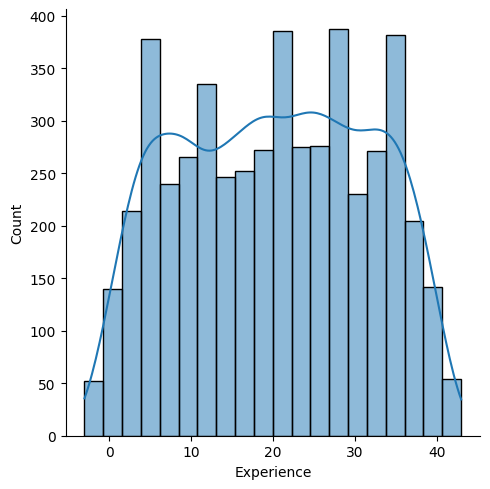

In [17]:
# Let's visualize the distribution of the Experience variable and examine its skewness to determine the most appropriate method for imputing missing values.

sns.displot(x=data["Experience"], kde=True);

In [18]:
# Processing Experience Column
data.loc[data['Experience']<0,'Experience']=np.abs(data['Experience'])

In [19]:
# Checking the value counts to confirm negative values are corrected
len(data[data["Experience"] < 0])

0

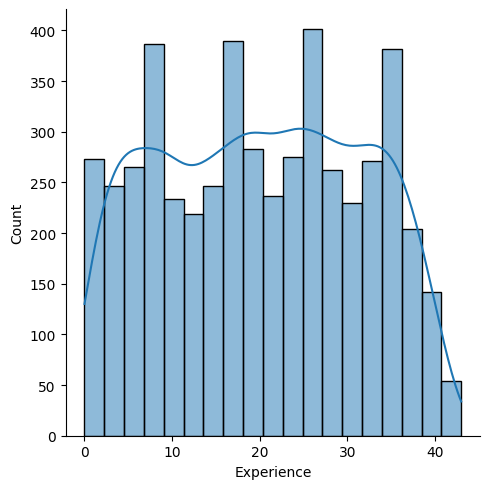

In [20]:
# Recheck visualization of the Experience variable - No more negative values.

sns.displot(x=data["Experience"], kde=True);

Zip code conversion

In [21]:
# checking the number of uniques in the zip code
data["ZIPCode"].nunique()

467

In [22]:
# Taking first 2 digits of the ZipCode
data["ZIPCode"] = data["ZIPCode"].astype(str)
print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    data["ZIPCode"].str[0:2].nunique(),
)
data["ZIPCode"] = data["ZIPCode"].str[0:2]

data["ZIPCode"] = data["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


In [23]:
## Converting the data type of categorical features to 'category'
cat_cols = [
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "ZIPCode",
]
data[cat_cols] = data[cat_cols].astype("category")

In [25]:
# Dropping ID Column
data.drop(['ID'],axis=1,inplace=True)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 269.8 KB


## Exploratory Data Analysis.

In [27]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0


**Observations:**

*  The Age of customers in our dataset ranges between 23 to 67 with Average 45
years old.
*  The Experience ranges from non experienced up to 43 years of experience.
*  The Income ranges between 8k per year up to 224k with average Income 73.77k.
*  The Average usage on credit cards is 1.93k monthly through our dataset with max of 10k per month.


In [28]:
data.corr()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
Age,1.000000,0.993991,-0.055269,-0.030632,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.993991,1.000000,-0.046876,-0.031294,-0.051851,-0.049738,0.013919,-0.011097,-0.008304,-0.000989,0.009735,0.014051,0.008851
Income,-0.055269,-0.046876,1.000000,-0.028900,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIPCode,-0.030632,-0.031294,-0.028900,1.000000,0.027603,-0.011658,-0.006804,0.004574,-0.000607,-0.000030,0.022558,0.025357,0.022317
Family,-0.046418,-0.051851,-0.157501,0.027603,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052012,-0.049738,0.645984,-0.011658,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.041334,0.013919,-0.187524,-0.006804,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.011097,0.206806,0.004574,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal_Loan,-0.007726,-0.008304,0.502462,-0.000607,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities_Account,-0.000436,-0.000989,-0.002616,-0.000030,0.019994,0.015086,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028


Observations:

*  Age and Experience show the strongest relationship, with older customers almost always having more years of experience. One of them can be dropped.

*  Income and CCAvg have a strong positive correlation, indicating that higher-income customers tend to spend more on their credit cards.

*  Income and Personal_Loan are strongly linked, as higher-income individuals are more likely to take personal loans.

*  CD_Account and Securities_Account show a moderate positive correlation, meaning customers with one investment product often hold the other.

*  CD_Account and CreditCard have a noticeable positive correlation, suggesting CD account holders are somewhat more likely to also have credit cards.



**Univariate Analysis**

In [29]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [30]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot.get_x() + p.get_width() / 2  # width of the plot

**Observations on Age**

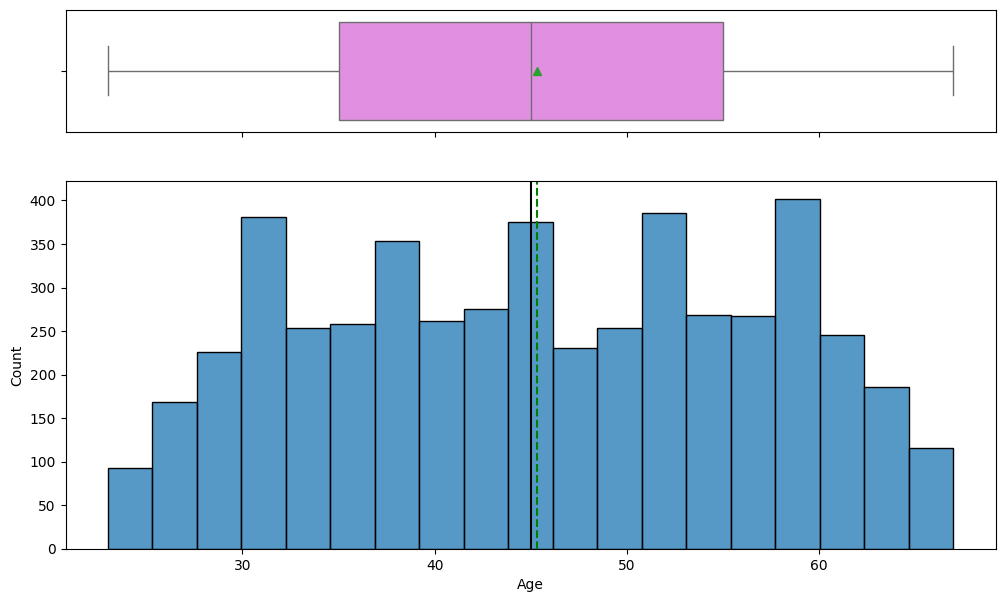

In [31]:
histogram_boxplot(data,'Age')


* The min is 23 , max is 67 , Average is 45 Years old - Data seems is slightly fitting a uniform distribution.
* The maximum number of clients is within the 58-60 years old range, there are also peak counts at 30-32, 38-40, 44-46 and 52-54 years old
* There are no outliers observed.



**Observations on Experience**

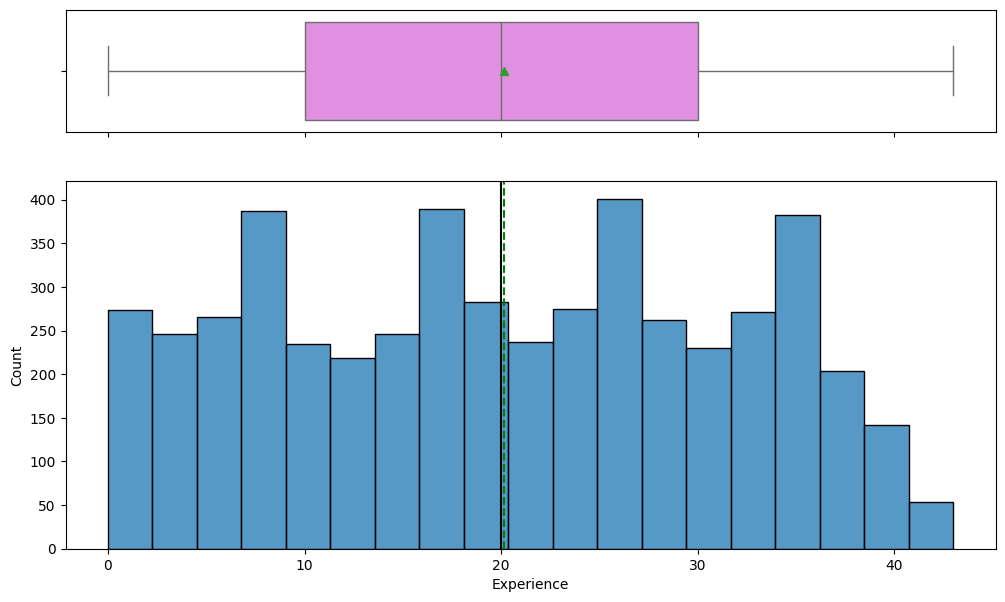

In [32]:
histogram_boxplot(data,'Experience')

* The min Experience is 0 years, the max is 43 and the mean is approximatly 20 years.
* The data is almost fitting a uniform distribution with peaks at 12-14 years and 28-30 years
* There are no outliers observed

**Observations on Income**

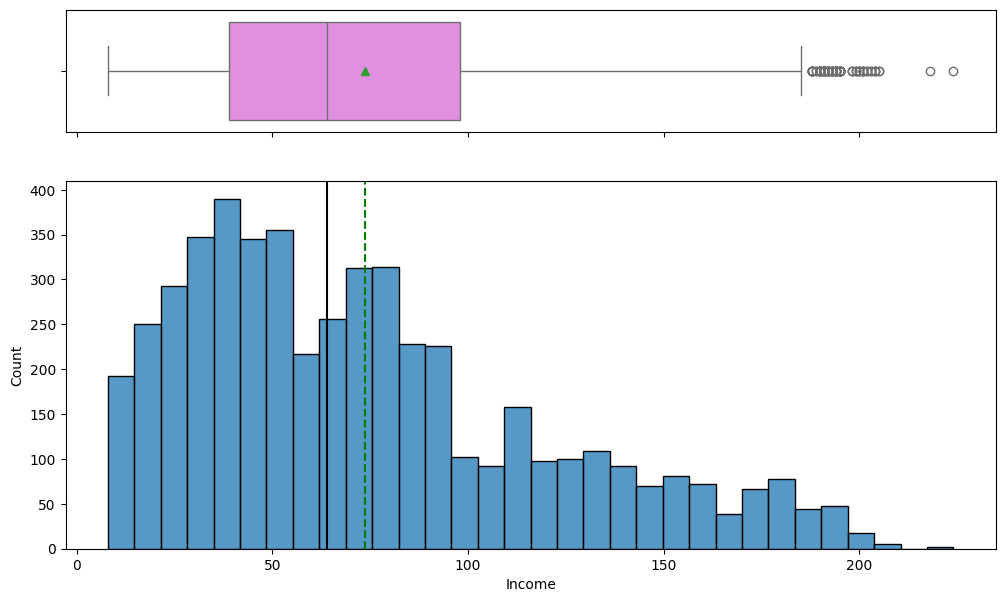

In [33]:
histogram_boxplot(data,'Income')

* The min Income is USD 46k, max is USD 224K and average is USD 64K - Dataset is right skewed
* There is a number of outliers, yet they seem consistent with the data hence no action is required for outlier treatment

**Observations on CCAvg**

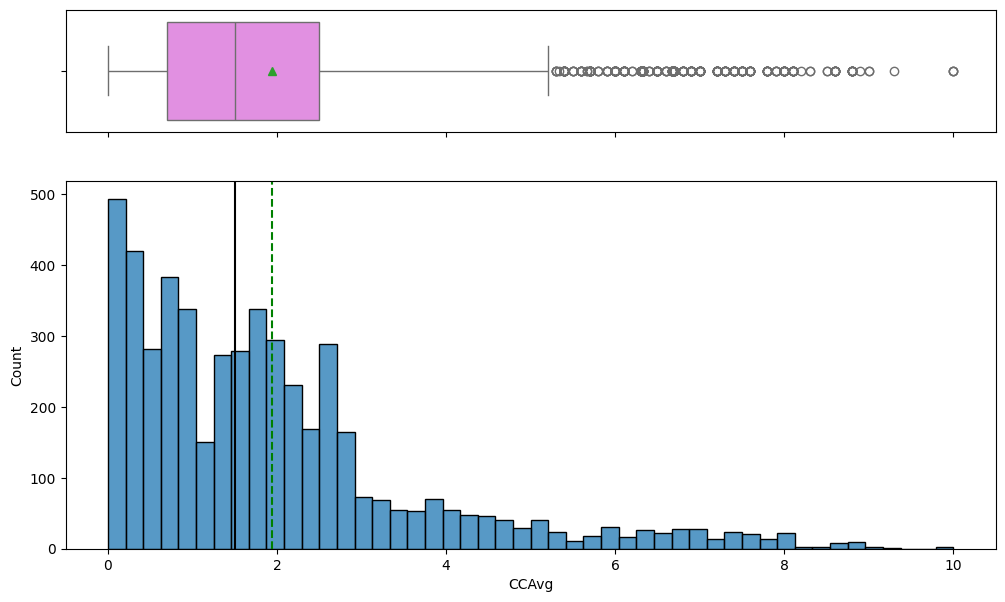

In [34]:
histogram_boxplot(data,'CCAvg')

* The min CCAvg is USD 0k (which can be reflecting customers who do not own credit cards), max is USD 1.9K and average is approx USD 1.9K
* Dataset is right skewed with a number of outliers that seem homogenous with the data, hence no action required for the outliers

**Observations on Mortgage**

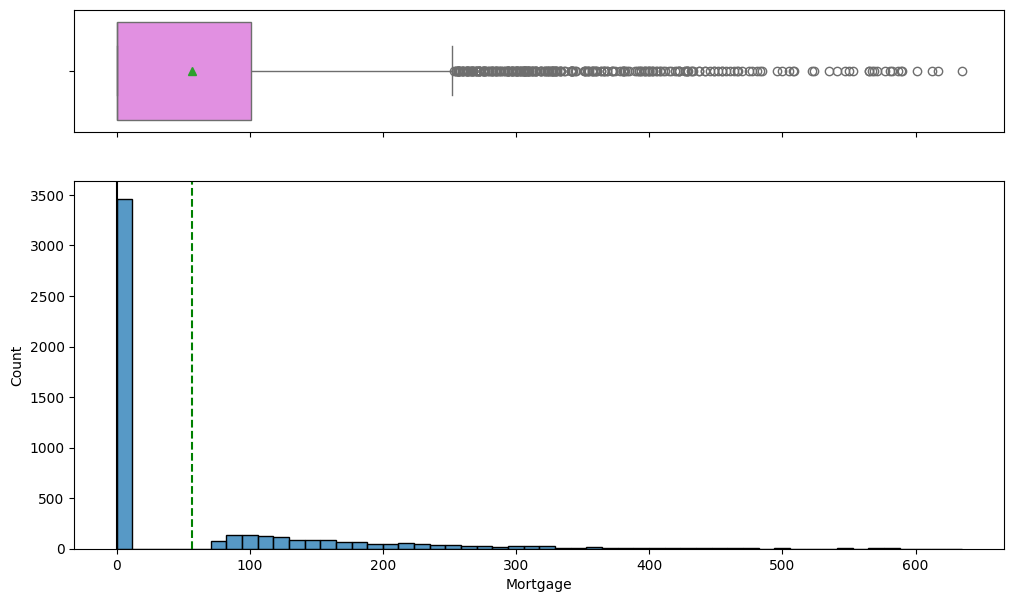

In [35]:
histogram_boxplot(data,'Mortgage')

* The min Mortgage is USD 0k, max is USD 635K and average is USD 0K - Dataset heavily right skewed
* To visualize better, we will separate the USD 0k mortgage from the > USD 0K mortgage and plot the data again

In [36]:
# Extracting the customers with mortgage values > 0
mortgage = data[data['Mortgage']>0]
print(f'There are {len(mortgage)} customers under mortgage and forms {round((len(mortgage)/5000)*100)}% of the dataset')

There are 1538 customers under mortgage and forms 31% of the dataset


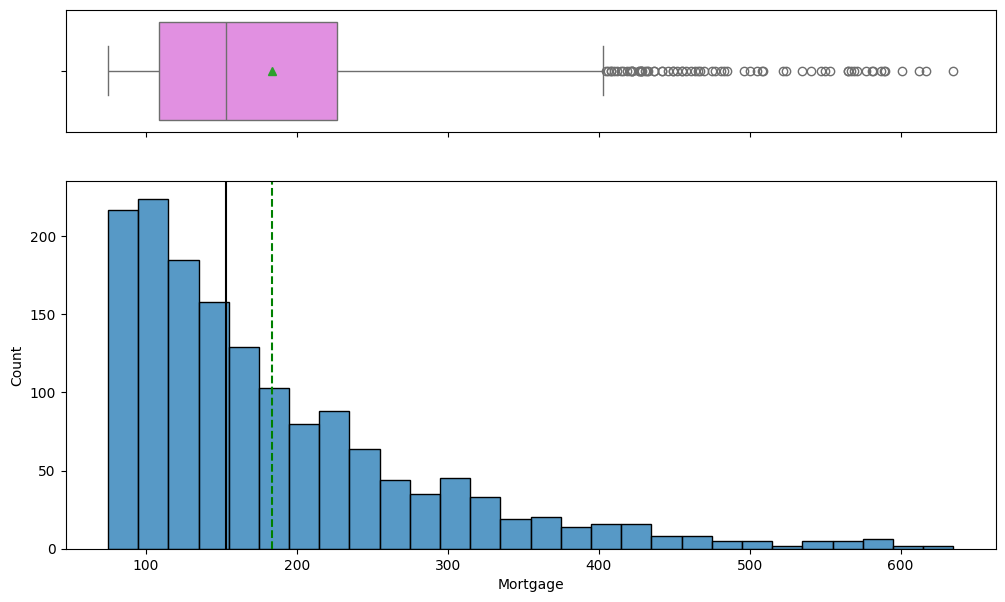

In [37]:
# Plotting the mortgage of the customers
histogram_boxplot(mortgage,'Mortgage')

* The mortgage distibution of the customers under mortgage is right skewed with a minimum value of approx 99K to max value of 635K and mean value between USD 180-200K .

# Visualizing the categorical data

In [47]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

Family size

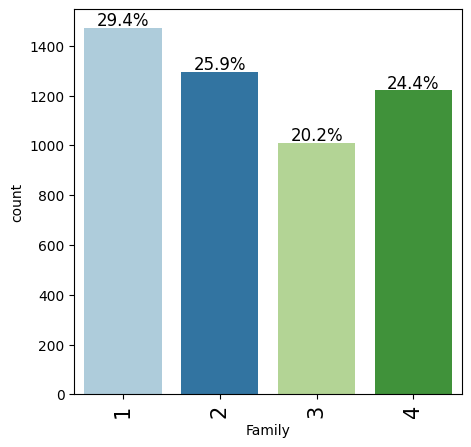

In [39]:
labeled_barplot(data,'Family',perc=True)

Observation:

The majority of Family sizes (29.4%) is size 1, followed by (25.9%) of size 2 then (24.4%) of size 4 and finally (20.2%) of size 3.

Education

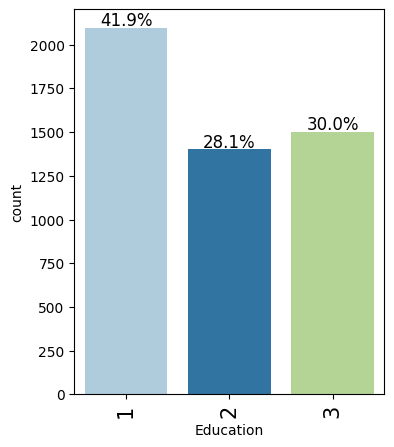

In [40]:
labeled_barplot(data,'Education',perc=True)

Observation:
* 41.9% of customers are 1: Undergrad
* 28.1% of customers are 2: Graduate
* 30.0% of customers are 3: Advanced/Professional

Personal_Loan

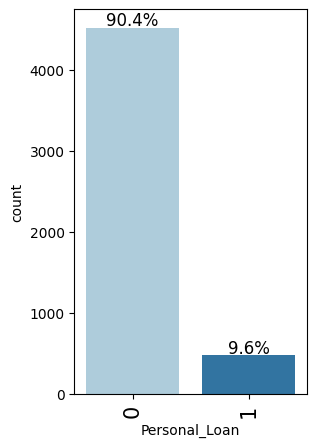

In [41]:
labeled_barplot(data,'Personal_Loan',perc=True)

Observation:

* 90.4% of customers Did not accept a loan
* 9.6% of customers accepted a loan
* This mismatch needs to be considered while training the model

CD_Account

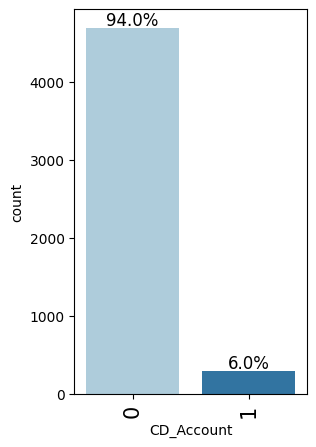

In [42]:
labeled_barplot(data,'CD_Account',perc=True)

Observation:
* 94% of customers Do Not have a CD_Account
* 6% only have a CD_Account

Online

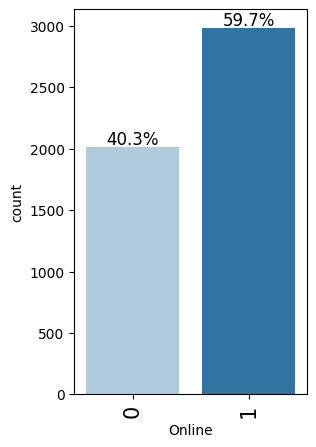

In [43]:
labeled_barplot(data,'Online',perc=True)

Observation:
* 59.7% of customers use the online banking services
* 40.3% of customers do not use the online banking services

CreditCard

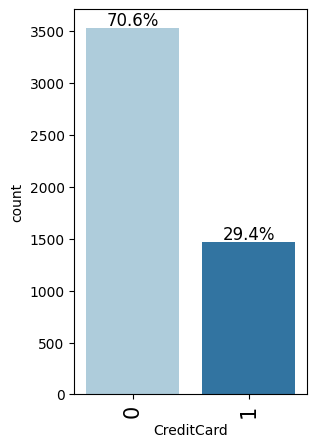

In [44]:
labeled_barplot(data,'CreditCard',perc=True)

Observation:
* 70.6% of customers do not use a credit card issued by a different bank
* 29.4% of customers use a credit card issued by a different bank

**Mutltivariate and Bi Variate Analysis**

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 269.8 KB


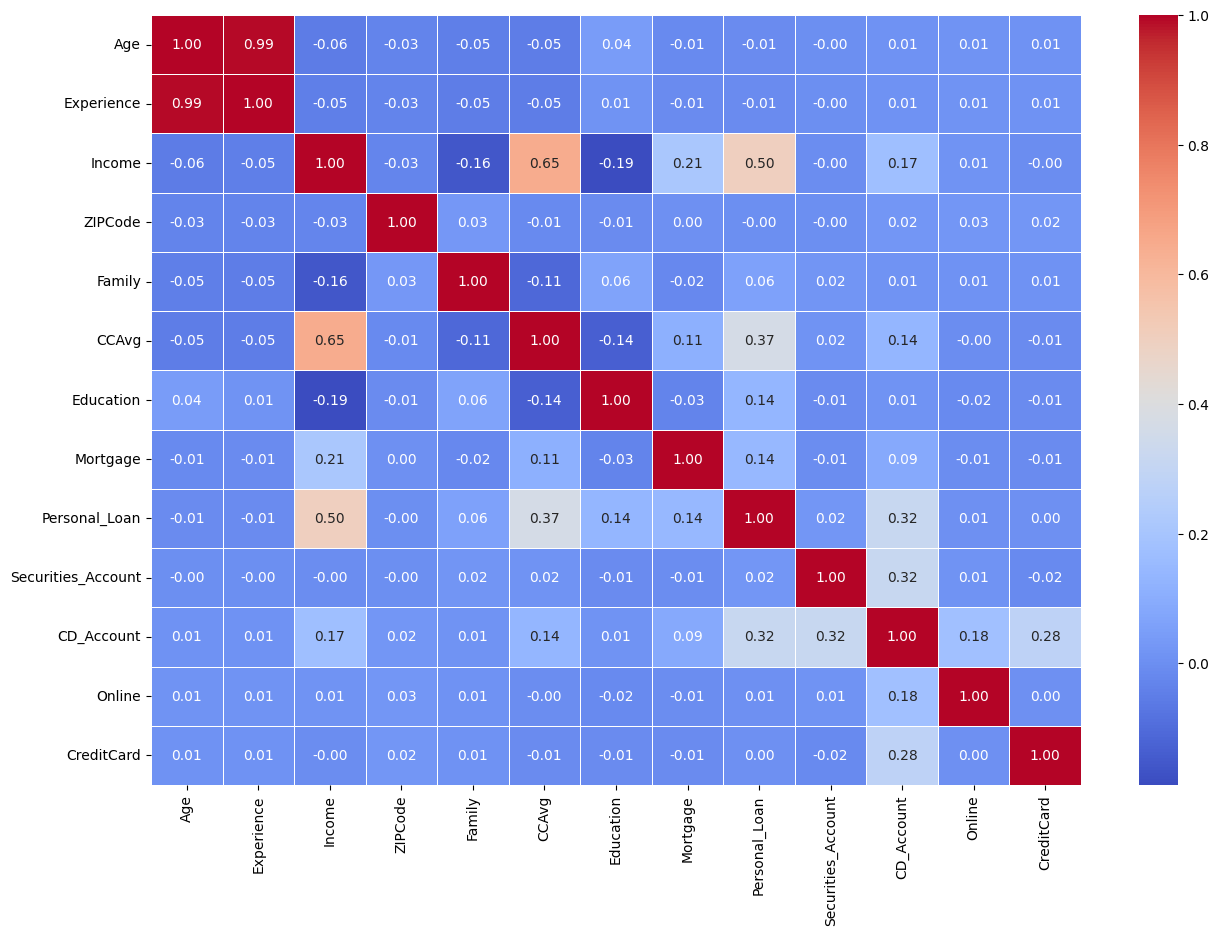

In [49]:
# Set a color palette for the heatmap
sns.set_palette(sns.color_palette("Set2", 8))

# Set figure size for better readability
plt.figure(figsize=(15, 10))

# Plot the correlation matrix as a heatmap
# annot=True displays correlation values on the heatmap
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Display the heatmap
plt.show()

Observations:

* Age and Experience have the strongest correlation (~0.99), indicating they almost measure the same trait.

* Income and CCAvg show a strong positive correlation (~0.65), meaning higher-income customers tend to spend more on credit cards.

* Income and Personal_Loan are moderately correlated (~0.50), suggesting higher-income customers are more likely to take personal loans.

* CCAvg and Personal_Loan have a moderate correlation (~0.37), showing that high spenders are more likely to use personal loans.

* CD_Account and Personal_Loan show a moderate correlation (~0.32), indicating customers with CD accounts are more likely to take personal loans.

In [ ]:
# Set a color palette for the pairplot
sns.set_palette(sns.color_palette("Set3", 8))

# Create pairwise scatter plots for selected numeric variables
# hue="Personal_Loan" colors points based on target variable
sns.pairplot(
    data,
    vars=['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage'],
    hue="Personal_Loan",
    diag_kind="kde",   # Using KDE plots on the diagonal for density visualization
    height=2.5         # Size of each subplot
)

# Display the plot
plt.show()


In [ ]:
# List of numeric columns to plot
numeric_columns = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# Set figure size for all subplots
plt.figure(figsize=(15, 25))

# Loop through each numeric column to create a boxplot
for i, variable in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns), 1, i + 1)  # One subplot per row

    # Create a boxplot of the variable vs Personal_Loan
    sns.boxplot(
        x='Personal_Loan',
        y=data[variable],
        data=data,
        palette=['skyblue', 'salmon']
    )

    # Remove top, right, and left spines for cleaner look
    sns.despine(top=True, right=True, left=True)

    # Add a title to each subplot
    plt.title(variable.upper(), fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


In [ ]:
def stacked_plot(x):
    """
    Plots a stacked bar chart of Personal_Loan vs a categorical variable.

    Parameters:
    x : pandas Series
        The categorical variable to plot against 'Personal_Loan'.
    """
    # Set color palette for the plot
    sns.set_palette(sns.color_palette("Set1", 8))

    # Show raw counts in a crosstab
    tab_counts = pd.crosstab(x, data['Personal_Loan'], margins=True)
    print("Counts:\n", tab_counts)
    print('-' * 120)

    # Compute normalized percentages for stacked plot
    tab_percent = pd.crosstab(x, data['Personal_Loan'], normalize='index')

    # Plot stacked bar chart
    tab_percent.plot(kind='bar', stacked=True, figsize=(7, 4))

    # Customize x-axis and legend
    plt.xticks(rotation=0)  # Horizontal labels
    labels = ["No", "Yes"]
    plt.legend(
        title="Borrowed Loan",
        labels=labels,
        loc="upper left",
        bbox_to_anchor=(1, 1),
        frameon=False
    )

    # Remove top, right, and left spines for a cleaner look
    sns.despine(top=True, right=True, left=True)

    # Display the plot
    plt.tight_layout()
    plt.show()


In [ ]:
cat_columns=['Family','Education','Securities_Account','CD_Account','CreditCard','Online',]
for i, variable in enumerate(cat_columns):
       stacked_plot(data[variable])

Based on exploratory data analysis we can conclude that :

* Customers with family size of 3 have a higher conversion rate

* The more educated the customers are the higher conversion rate, as we can see that customers with advanced/Professional degree have a higher probability to take a personal loan.

* Customers with Securities Account represents higher conversion rate to take a personal loan.

* Customers who have a CD account shows significant conversion to take a perosnal through our dataset.

* Customers who have an Online Account shows a little bit higher conversion rate than customers who don't have online account.

* Customers who have a Credit card shows a little bit higher conversion rate than those who don't.

* Customers who have a Higher average usage on thier Credit Cards shows a higher conversion rate comparing to others.

* Customers with Higher Income shows higher probability to take a personal loan.

* Customers who have Mortgage with us tends to take a personal loan more than others.

Recommendations on Targeting Personal Loan customers.

* In next Marketing campaign, Exploratorty data analysis recommends to target customers with family size of 3 or more has they have higher probability to take a personal loan.

* we may need to focus on well educated customers as a graduate or professionals if we're seeking in higher conversion rate for Personal loan.

* we need to get closer to customers with CD account and Securities account to understand thier needs and providing them with latest offers on personal loans.

* focusing on customers with High income Profile shows higher conversion rate than other customers, targeting this segment will result in higher conversion rate for the personal loan.

* we can target customers who have a higher average usage and High value of Mortgage as they represents higher probabilty to take a personal loan.

#Outlier Detection

In [ ]:
# List of numeric columns to check for outliers
numeric_columns = ['Income', 'CCAvg', 'Mortgage', 'Experience', 'Age']

# Set figure size
plt.figure(figsize=(10, 20))

# Loop through each numeric column and plot a boxplot
for i, variable in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns), 1, i + 1)  # One subplot per row

    # Create a boxplot with whiskers at 1.5*IQR
    plt.boxplot(data[variable], whis=1.5)

    # Add title for each subplot
    plt.title(variable, fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


Observation:

* There are small number of outliers in the Income Column and some more Outliers in the Higher part of CCAvg and Mortgage variable.

* This could be indication of real balanced dataset as the amount of outliers in each variable is not significant enough to affect our model. so we will keep the outliers without treatment to present real-life case.

### Data Preparation for Modeling

In [ ]:
# Dropping Experience as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = X.astype(float)

# Splitting data in train and test sets - 30% to Test and 70% to train
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [ ]:
# Checking the train and test dataset sizes for confirmation and printing as formatted String
print(f'X_train shape:{X_train.shape}')
print(f'X_test shape:{X_test.shape}')

In [ ]:
# Checking the percentage of target variable classes in the train and test sets
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True).rename("Percentage"))

print("\nPercentage of classes in test set:")
print(y_test.value_counts(normalize=True).rename("Percentage"))

## Model Building

### Model Evaluation Criterion

Model can make wrong predictions as:

* Predicting a customer will accept a loan but in reality the customer would not accept a loan. - Loss of resources

* Predicting a customer will not accept a loan but in reality the customer would have accepted a loan. - Loss of opportunity

* If we predict a customer who was going to accept a loan as a customer who will not accept a loan - loss of opportunity (FN)

* Recall should be maximized, the greater the recall higher the chances of minimizing the false negatives.


In [ ]:
##  Function to calculate recall score
def get_recall_score(model, predictors, target):
    """
    model: classifier
    predictors: independent variables
    target: dependent variable

    """
    prediction = model.predict(predictors)
    return recall_score(target, prediction)

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

### Decision Tree (default)

In [ ]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

# Checking model performance on training data

In [ ]:
confusion_matrix_sklearn(model, X_train, y_train)
plt.title("Confusion Matrix - Training Set");

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

Observations:

* The model predicts every training sample correctly, resulting in zero misclassifications in the confusion matrix.

* All class-0 (3169 samples) and class-1 (331 samples) observations are perfectly classified.

* The training accuracy, precision, recall, and F1-score are all 1.0, indicating flawless performance on the training data.

* This perfect performance is a strong indication of overfitting, especially for a decision tree model.

* The data is imbalanced (about 90% class-0 and 10% class-1), yet the model still predicts both classes perfectly, showing it has likely memorized the training set.

* The training metrics do not reflect the model’s true generalization ability, so evaluating the test set is essential.

In [ ]:
confusion_matrix_sklearn(model, X_test, y_test)
plt.title("Confusion Matrix - Test Set");

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

Observations:

* The model achieves 98% accuracy on the test set, which is strong and indicates good generalization despite overfitting on the training data.

* The confusion matrix shows 13 false positives (class 0 predicted as class 1) and 17 false negatives (class 1 predicted as class 0).

* False negatives (17 cases) are especially important because they represent customers who would take the loan but were predicted as non-loan takers.

* The recall for class 1 is reflected in the overall recall score of 0.8859, meaning the model captures around 88.6% of the actual loan takers.

* The precision score of 0.9103 indicates that when the model predicts class 1, it is correct 91% of the time.

* The F1 score of 0.898 shows a good balance between precision and recall for the positive class.

* Compared to the perfect training results, the drop in test performance confirms the model was overfitting, but still generalizes reasonably well.

* The test confusion matrix reflects the natural imbalance: most predictions are still toward class 0, but the minority class is reasonably well detected.

* Overall, the model performs well on the test set, but tuning (e.g., pruning, limiting depth) could further improve recall on the minority class and reduce overfitting.

# Visualizing Decision Tree

In [ ]:
# Extract the column names from the training set as a list
feature_names = list(X_train.columns)

# Display the feature names
print("Feature names:", feature_names)


In [ ]:
# Set figure size for better readability
plt.figure(figsize=(20, 30))

# Plot the decision tree
# filled=True colors nodes based on majority class
# fontsize=9 sets readable font size for labels
# node_ids=False hides node indices
out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None  # You can provide class names if desired
)

# Ensure arrows (edges) connecting nodes are visible
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")  # Set arrow color
        arrow.set_linewidth(1)        # Set arrow thickness

# Display the tree
plt.show()


In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model, feature_names=feature_names, show_weights=True))

In [ ]:
# Creating a sorted and well-formatted table of feature importances

feature_imp = (
    pd.DataFrame({"Importance": model.feature_importances_}, index=X_train.columns)
    .sort_values("Importance", ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

print(feature_imp)


In [ ]:
# Get feature importances from the trained model
importances = model.feature_importances_

# Sort feature indices by importance (ascending)
sorted_idx = np.argsort(importances)

# Plot feature importances
plt.figure(figsize=(8, 8))
plt.title("Feature Importances", fontsize=14)

plt.barh(
    y=range(len(sorted_idx)),
    width=importances[sorted_idx],
    align="center",
)

# Label each bar with the corresponding feature name
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])

plt.xlabel("Relative Importance", fontsize=12)
plt.tight_layout()
plt.show()


Observations:

*  Education is the most important feature, contributing the highest relative importance to the model.

* Income is the second most influential feature, though noticeably lower than Education.

* Family has moderate importance, suggesting household size has some predictive power.

* CCAvg (average credit card spending) and Age have relatively low but non-negligible importance.

* CD_Account has a small contribution, indicating it is less relevant to the model.

* Mortgage has minimal importance among the features.

* Online, CreditCard, Securities_Account, and ZIPCode have negligible or zero importance, implying they do not meaningfully influence the model predictions.

* Overall, demographic and financial features like Education, Income, and Family are driving the model, while account ownership and geographic features are largely irrelevant.



## Model Performance Improvement

Implemented 2 different Hyperparameter grids to compare and take a call based on Preceison, Recall, Accuracy and F1 score

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

In [ ]:
# Define the hyperparameter grid
param_grid = {
  "max_depth": np.arange(3, 16, 2),          # Shallow to moderately deep trees
  "max_leaf_nodes": [20, 50, 100, 200, 300], # Control tree complexity
  "min_samples_split": [2, 5, 10, 20, 50],   # Minimum samples required to split
  "min_samples_leaf": [1, 5, 10, 20],        # Minimum samples required in a leaf
  "max_features": [None, "sqrt", "log2"],    # Number of features considered at each split
  "criterion": ["gini", "entropy"]           # Splitting criterion
}



# Initialize variables to store the best model and performance
best_estimator_new = None
best_score_diff = float('inf')
best_test_recall = 0.0

# Iterate over all combinations of parameters
for max_depth in param_grid["max_depth"]:
    for max_leaf_nodes in param_grid["max_leaf_nodes"]:
        for min_samples_split in param_grid["min_samples_split"]:

            # Initialize Decision Tree with current parameters
            model = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model on training data
            model.fit(X_train, y_train)

            # Predict on training and test sets
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            # Compute recall scores
            train_recall = recall_score(y_train, y_train_pred)
            test_recall = recall_score(y_test, y_test_pred)

            # Absolute difference between training and test recall
            score_diff = abs(train_recall - test_recall)

            # Update best model if criteria are met
            if (score_diff < best_score_diff) and (test_recall > best_test_recall):
                best_score_diff = score_diff
                best_test_recall = test_recall
                best_estimator_new = model

# Display best parameters and performance
print("Best parameters found:")
print(f"Max depth: {best_estimator_new.max_depth}")
print(f"Max leaf nodes: {best_estimator_new.max_leaf_nodes}")
print(f"Min samples split: {best_estimator_new.min_samples_split}")
print(f"Best test recall score: {best_test_recall:.4f}")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Assuming these are your models
# model -> from previous (original) grid (un-tuned Decision Tree)
# best_estimator_new  -> from optimized grid

# Predictions on test set
y_pred_orig = model.predict(X_test) # Using 'model' as the original/untuned estimator
y_pred_new = best_estimator_new.predict(X_test)

# Classification reports
print("===== Original Grid Model (Untuned) ====")
print(classification_report(y_test, y_pred_orig))

print("===== Optimized Grid Model ====")
print(classification_report(y_test, y_pred_new))

# Optional: Confusion matrices for visual comparison
print("Confusion Matrix - Original Grid Model (Untuned)")
print(confusion_matrix(y_test, y_pred_orig))

print("Confusion Matrix - Optimized Grid Model")
print(confusion_matrix(y_test, y_pred_new))

Observations – Original Grid Model (Untuned)

* Class 1 (minority/positive class) recall is very high (0.96) → most positive cases are detected.

* Class 1 precision is moderate (0.75) → some false positives (48) but acceptable.

* Class 1 F1-score is 0.84 → good balance between precision and recall.

* Class 0 (majority/negative class) precision and recall are very high (1.00 and 0.96).

* Overall accuracy is 0.96.

* Confusion matrix shows very few false negatives (6) → minimal missed positives.

---

Observations – Optimized Grid Model

* Class 1 recall is slightly lower (0.93) → misses more positives than original.

* Class 1 precision drops to 0.69 → more false positives (62).

* Class 1 F1-score is 0.79 → lower than original model.

* Class 0 metrics are slightly lower than original (precision 0.99, recall 0.95).

* Overall accuracy is 0.95 → slightly lower than original.

* Confusion matrix shows more false negatives (10) and false positives (62).



---


| Metric / Class          | Original Grid Model | Optimized Grid Model | Observation                            |
| ----------------------- | ------------------- | -------------------- | -------------------------------------- |
| Class 1 Recall          | 0.96                | 0.93                 | Original better at detecting positives |
| Class 1 Precision       | 0.75                | 0.69                 | Original has fewer false positives     |
| Class 1 F1-score        | 0.84                | 0.79                 | Original has better balance            |
| Class 1 False Negatives | 6                   | 10                   | Original misses fewer positives        |
| Class 1 False Positives | 48                  | 62                   | Original has fewer false positives     |
| Class 0 Recall          | 0.96                | 0.95                 | Slightly better in original            |
| Class 0 Precision       | 1.00                | 0.99                 | Slightly better in original            |
| Overall Accuracy        | 0.96                | 0.95                 | Original slightly higher               |


---

* Original Grid Model outperforms the Optimized Grid Model in terms of recall, F1-score, and false negatives for the minority class (class 1).



In [ ]:
# Creating the decision Tree with the Original Grid Model

# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)


In [ ]:
 # Compute the confusion Matrix for best estimate model for training data
 confusion_matrix_sklearn(model2, X_train, y_train)
 plt.title("Confusion Matrix - Training Set");

In [ ]:
# This line calculates the full set of classification performance metrics for model2 on the training data, and stores the results in decision_tree_tune_perf_train.
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

In [ ]:
 # Compute the confusion Matrix for best estimate model for test data
confusion_matrix_sklearn(model2, X_test, y_test)
plt.title("Confusion Matrix - Test Set");

In [ ]:
# This line calculates the full set of classification performance metrics for model2 on the test data, and stores the results in decision_tree_tune_perf_test.
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

Observations:

* The train and test accuracy scores (0.790 vs. 0.779) are very close, indicating the model is not overfitting.

* Recall is identical at 1.0 for both train and test sets, showing the model consistently captures all positive cases.

* Precision is nearly the same (0.3108 vs. 0.3104), suggesting the model’s false-positive behavior generalizes similarly to unseen data.

* The F1 scores (0.4742 vs. 0.4738) are almost identical, confirming stable performance across train and test sets.

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

In [ ]:
# Creating a sorted and well-formatted table of feature importances

feature_imp = (
    pd.DataFrame({"Importance": model2.feature_importances_}, index=X_train.columns)
    .sort_values("Importance", ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

print(feature_imp)

In [ ]:
# Get feature importances from the trained model
importances = model2.feature_importances_

# Sort feature indices by importance (ascending)
sorted_idx = np.argsort(importances)

# Plot feature importances
plt.figure(figsize=(8, 8))
plt.title("Feature Importances", fontsize=14)

plt.barh(
    y=range(len(sorted_idx)),
    width=importances[sorted_idx],
    align="center",
)

# Label each bar with the corresponding feature name
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])

plt.xlabel("Relative Importance", fontsize=12)
plt.tight_layout()
plt.show()

Observations:

* Income is by far the most important predictor, contributing over 80% to the model’s decisions.

* Education has the second-highest importance but is significantly lower than Income.

* CCAvg (Credit Card Average Spending) also contributes modestly, ranking third.

* All other features — including CD_Account, Online, CreditCard, Mortgage, Securities_Account, Family, ZIPCode, and Age — have near-zero importance, indicating they add minimal predictive value to the model.

# Decision Tree Post Pruning

In [ ]:
# Initialize a Decision Tree classifier
# random_state=1 ensures reproducibility
# class_weight="balanced" adjusts weights inversely proportional to class frequencies
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Compute the effective alpha values for Minimal Cost-Complexity Pruning
# This returns a dictionary with 'ccp_alphas' (alpha values) and 'impurities' (total leaf impurities)
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the alpha values and corresponding impurities
# Taking absolute value of ccp_alphas to avoid any negative values (for safety)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
# Display the DataFrame
pd.DataFrame(path)

In [ ]:
# Plot total leaf impurity vs effective alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas[:-1], impurities[:-1], 'o-', drawstyle='steps-post', markersize=6)

# Add labels and title
plt.xlabel("Effective Alpha")
plt.ylabel("Total Impurity of Leaves")
plt.title("Training Set: Total Impurity vs Effective Alpha")

# Optional: add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
# Train a Decision Tree for each alpha value and store them in a list
clfs = [
    DecisionTreeClassifier(random_state=1, ccp_alpha=alpha, class_weight="balanced").fit(X_train, y_train)
    for alpha in ccp_alphas
]

# Display the number of nodes in the last (fully pruned) tree
print(f"Number of nodes in the last tree: {clfs[-1].tree_.node_count} with ccp_alpha: {ccp_alphas[-1]}")

In [ ]:
# Remove the last tree and alpha (fully pruned tree)
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract number of nodes and depth for each tree
node_counts = [clf.tree_.node_count for clf in clfs]
depths = [clf.tree_.max_depth for clf in clfs]

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Plot number of nodes vs alpha
axes[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post", color='blue')
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Number of Nodes")
axes[0].set_title("Number of Nodes vs Alpha")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot tree depth vs alpha
axes[1].plot(ccp_alphas, depths, marker="o", drawstyle="steps-post", color='green')
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Depth of Tree")
axes[1].set_title("Depth vs Alpha")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Adjust layout for better spacing
fig.tight_layout()

# Display the plots
plt.show()

In [ ]:
# List to store recall scores for each tree on the training set
recall_train = []

# Compute recall for each trained classifier
for clf in clfs:
    y_pred_train = clf.predict(X_train)          # Make predictions on training data
    recall = recall_score(y_train, y_pred_train) # Calculate recall
    recall_train.append(recall)                  # Store recall value

In [ ]:
# List to store recall scores for each tree on the test set
recall_test = []

# Compute recall for each trained classifier on the test data
for clf in clfs:
    y_pred_test = clf.predict(X_test)          # Make predictions on test data
    recall = recall_score(y_test, y_pred_test) # Calculate recall
    recall_test.append(recall)                 # Store recall value

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 5))

# Plot recall vs alpha for training set
ax.plot(
    ccp_alphas,
    recall_train,
    marker="o",
    drawstyle="steps-post",
    label="Train",
    color="blue"
)

# Plot recall vs alpha for test set
ax.plot(
    ccp_alphas,
    recall_test,
    marker="o",
    drawstyle="steps-post",
    label="Test",
    color="red"
)

# Set axis labels and title
ax.set_xlabel("Alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs Alpha for Training and Testing Sets")

# Add legend and grid for clarity
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# Show the plot
plt.show()



In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
model3 = clfs[index_best_model]
print(model3)

In [ ]:
confusion_matrix_sklearn(model3, X_train, y_train)
plt.title("Confusion Matrix - Training Set");

In [ ]:
# Evaluate the performance of the trained Decision Tree model on the training set
# `model_performance_classification_sklearn` returns metrics like
# accuracy, precision, recall, F1-score
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model3, X_train, y_train
)

# Display the performance metrics
decision_tree_post_perf_train


In [ ]:
confusion_matrix_sklearn(model3, X_test, y_test)
plt.title("Confusion Matrix - Test Set");

In [ ]:
# Evaluate the performance of the trained Decision Tree model on the test set
# `model_performance_classification_sklearn` returns metrics like
# accuracy, precision, recall, F1-score
decision_tree_post_test = model_performance_classification_sklearn(
    model3, X_test, y_test
)
decision_tree_post_test

In [ ]:
# Set figure size for better readability
plt.figure(figsize=(20, 10))

# Plot the decision tree
# filled=True colors nodes based on majority class
# fontsize=9 ensures labels are readable
# node_ids=False hides node indices
out = tree.plot_tree(
    model3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,  # Can provide class names if desired
)

# Customize the arrows (edges) connecting nodes
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")  # Set arrow color
        arrow.set_linewidth(1)        # Set arrow thickness

# Display the tree
plt.show()


In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

In [ ]:
# Creating a sorted and well-formatted table of feature importances

feature_imp = (
    pd.DataFrame({"Importance": model3.feature_importances_}, index=X_train.columns)
    .sort_values("Importance", ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

print(feature_imp)

In [ ]:
# Get feature importances from the trained model
importances = model3.feature_importances_

# Sort feature indices by importance (ascending)
sorted_idx = np.argsort(importances)

# Plot feature importances
plt.figure(figsize=(8, 8))
plt.title("Feature Importances", fontsize=14)

plt.barh(
    y=range(len(sorted_idx)),
    width=importances[sorted_idx],
    align="center",
)

# Label each bar with the corresponding feature name
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])

plt.xlabel("Relative Importance", fontsize=12)
plt.tight_layout()
plt.show()

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Post-Pruning provides the most balanced performance across all metrics — high accuracy (0.9487), very high recall (0.9933), and significantly better precision (0.6607) than the pre-pruned model. It avoids overfitting seen in the default model while maintaining strong generalization.

## Actionable Insights and Business Recommendations


Have successfully developed a predictive model that:

a) Enables the bank to identify customers who are likely to be interested in taking a personal loan.

b) Highlights the key factors that influence whether a customer opts for a personal loan.

Key Factors Influencing Personal Loan Uptake:

* Income

* Family Size

* Education Level

Insights & Recommendations:

* Target higher-income customers: Individuals earning above $116k with a family size greater than 2 show a significantly higher likelihood of taking a personal loan.

* Education level matters: Customers with education levels above undergraduate are more inclined to opt for personal loans.

* Family size correlation: A larger family (3 or more members) is positively correlated with personal loan adoption.

* CD account holders: Approximately 50% of customers with a Certificate of Deposit (CD_Account) also show interest in personal loans. These customers should be prioritized for targeted marketing.

* Prioritize high-income, educated, and engaged customers

    Create micro-segments:

    Segment A: Income > $116K + Graduate/Professional + High deposit balance

    Segment B: Mid income + strong existing relationship

    Segment C: Digital-active customers

    Run separate offers for each segment.

___